# Task1

In [14]:
import numpy as np
import matplotlib.pyplot as plt

In [15]:
class LinearRegressionGD:
    """
    Linear Regression using Gradient Descent
    """
    def __init__(self, learning_rate=0.001, n_iters=100, alpha=0.0, l1_ratio=0.0):
        self.learning_rate = learning_rate
        self.n_iters = n_iters
        self.theta_0 = 0
        self.theta_1 = 0
        self.sse_history = []
        self.alpha = alpha
        self.l1_ratio = l1_ratio

    def fit(self, x, y):
        n = len(x)
        for _ in range(self.n_iters):
            y_pred = self.theta_0 + self.theta_1 * x

            d_theta_0 = (-2/n) * np.sum(y - y_pred)
            d_theta_1 = (-2/n) * np.sum((y - y_pred) * x)

            if self.alpha > 0:
                # L2 (Ridge) term
                d_theta_1 += self.alpha * (1 - self.l1_ratio) * 2 * self.theta_1
                # L1 (Lasso) term
                d_theta_1 += self.alpha * self.l1_ratio * np.sign(self.theta_1)

            self.theta_0 -= d_theta_0 * self.learning_rate
            self.theta_1 -= d_theta_1 * self.learning_rate

            sse = np.sum((y - y_pred) ** 2)
            self.sse_history.append(sse)

    def predict(self, x):
        return self.theta_0 + self.theta_1 * x

    def plot_training(self, X, y):
        plt.figure(figsize=(12,4))

        plt.subplot(1,2,1)
        plt.plot(self.sse_history)
        plt.title('SSE over iterations')
        plt.xlabel('Iteration')
        plt.ylabel('SSE')

        plt.subplot(1,2,2)
        plt.scatter(X, y, color='red')
        x_line = np.linspace(min(X), max(X), 100)
        y_line = self.predict(x_line)
        plt.plot(x_line, y_line, color='blue')
        plt.title('Regression line')
        plt.xlabel('X')
        plt.ylabel('y')

        plt.show()

    # Bouns
    def mse(self, X, y):
        y_pred = self.predict(X)
        return np.mean((y - y_pred) ** 2)

In [16]:
x = np.array([50, 60, 70, 80, 90])
y = np.array([150, 180, 210, 240, 270])
model = LinearRegressionGD(learning_rate=0.001, n_iters=500)
model.fit(x, y)
print(f"theta_0 = {model.theta_0:.4f}")
print(f"theta_1 = {model.theta_1:.4f}")

theta_0 = nan
theta_1 = nan


/tmp/ipykernel_551/1255545649.py:31: RuntimeWarning: overflow encountered in square
  sse = np.sum((y - y_pred) ** 2)
/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/tmp/ipykernel_551/1255545649.py:29: RuntimeWarning: invalid value encountered in scalar subtract
  self.theta_1 -= d_theta_1 * self.learning_rate


In [17]:
pred = model.predict(np.array([70]))
print(f"Predicted price for 70 m²: {pred[0]:.2f} ")

Predicted price for 70 m²: nan 


/usr/local/lib/python3.12/dist-packages/matplotlib/ticker.py:2176: RuntimeWarning: overflow encountered in multiply
  steps = self._extended_steps * scale


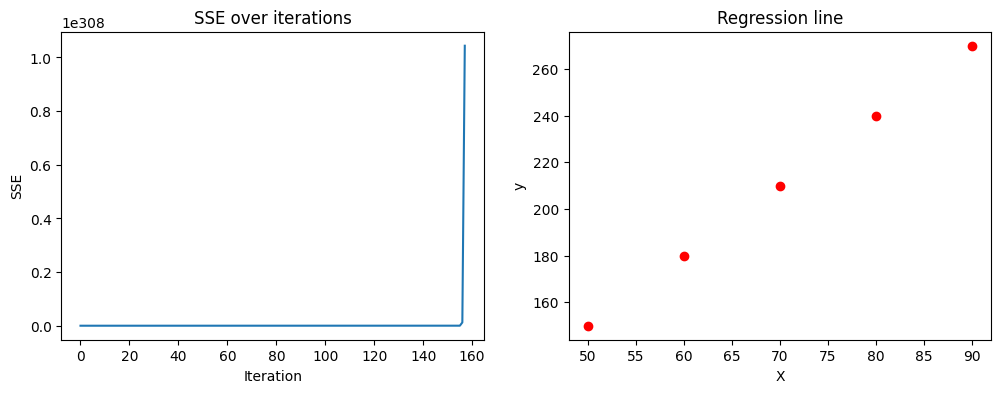

In [18]:
model.plot_training(x, y)

/tmp/ipykernel_551/1255545649.py:31: RuntimeWarning: overflow encountered in square
  sse = np.sum((y - y_pred) ** 2)


Big LR - theta_1: -2.007459532378114e+301
Small LR - theta_1: 2.9993713328364127


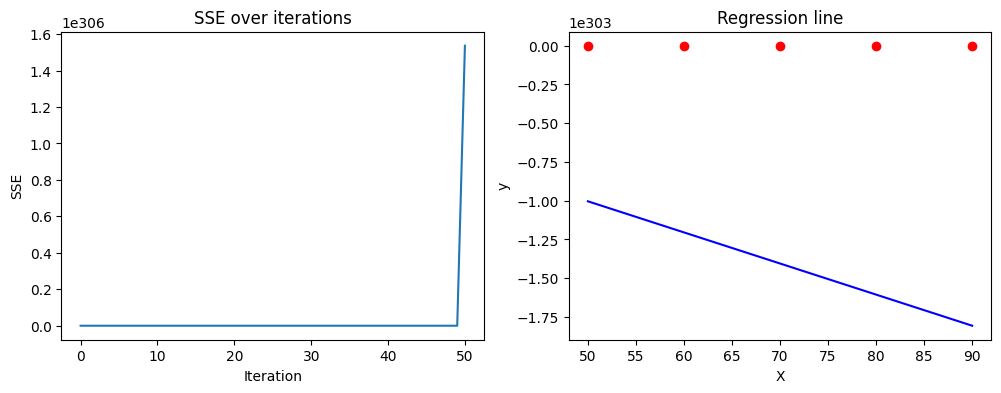

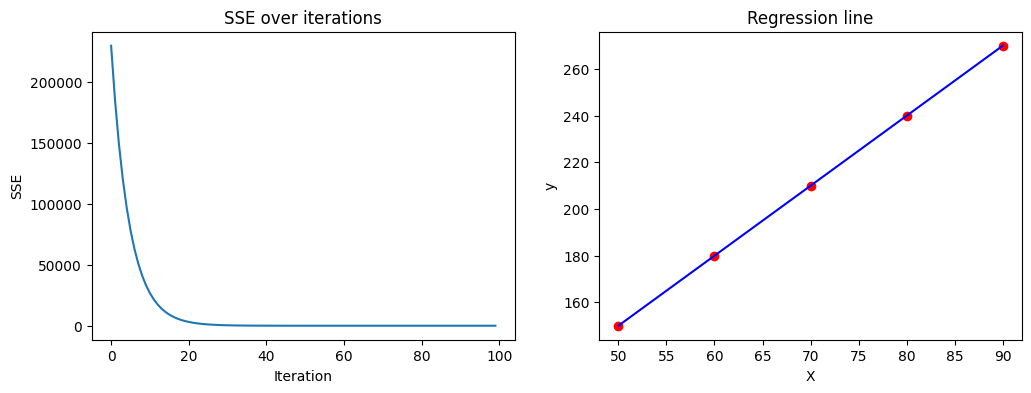

In [19]:
model_big = LinearRegressionGD(learning_rate=0.1, n_iters=100)
model_big.fit(x, y)

model_small = LinearRegressionGD(learning_rate=0.00001, n_iters=100)
model_small.fit(x, y)

print("Big LR - theta_1:", model_big.theta_1)
print("Small LR - theta_1:", model_small.theta_1)
model_big.plot_training(x, y)
model_small.plot_training(x, y)

### Bouns


In [20]:
print(f"MSE: {model.mse(x, y):.4f}")#big
print(f"MSE: {model_big.mse(x, y):.4f}")#so big
print(f"MSE: {model_small.mse(x, y):.4f}")#good

MSE: nan
MSE: inf
MSE: 0.0001


/tmp/ipykernel_551/1255545649.py:60: RuntimeWarning: overflow encountered in square
  return np.mean((y - y_pred) ** 2)


In [21]:
def normalize(X):
        return (X - np.mean(X)) / np.std(X)

--- Single Feature Models ---
Raw (no norm, no reg) - theta_1: 2.9994, MSE: 0.0001
Norm (no reg) - theta_1: 0.0848, MSE: 45716.7649
Ridge (norm) - theta_0: 0.0000, theta_1: 0.6068, MSE: 0.1546
Lasso (norm) - theta_0: 0.0000, theta_1: 0.6293, MSE: 0.1374
ElasticNet (norm) - theta_0: 0.0000, theta_1: 0.6181, MSE: 0.1458


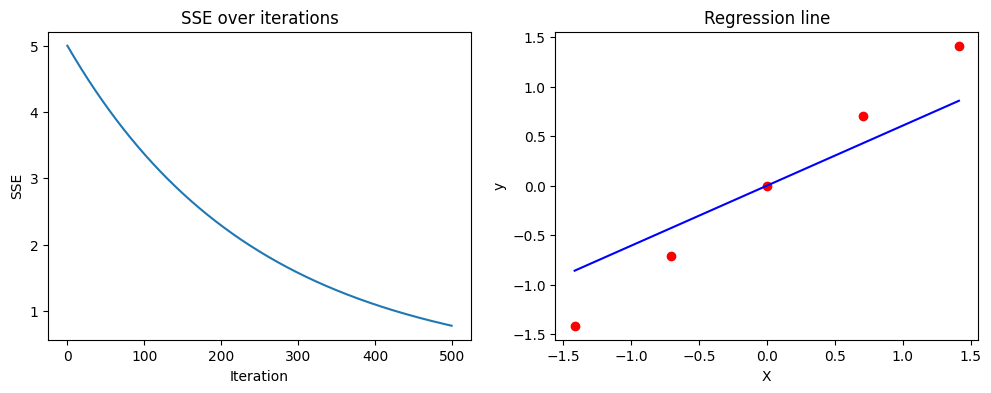

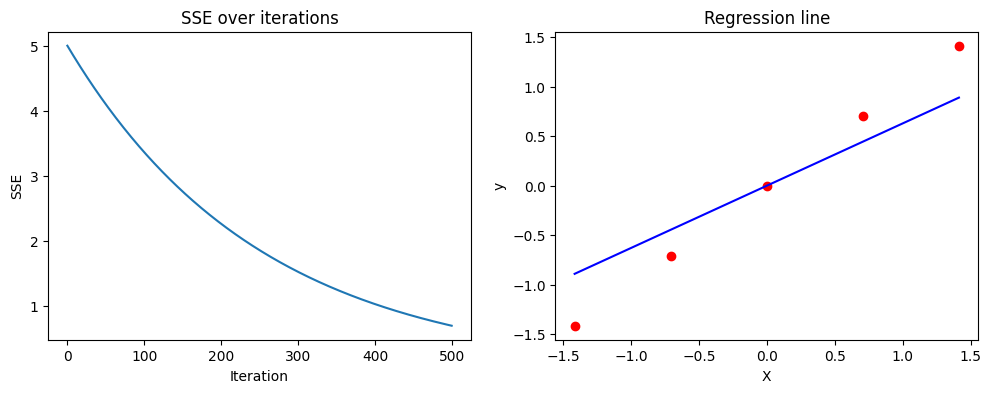

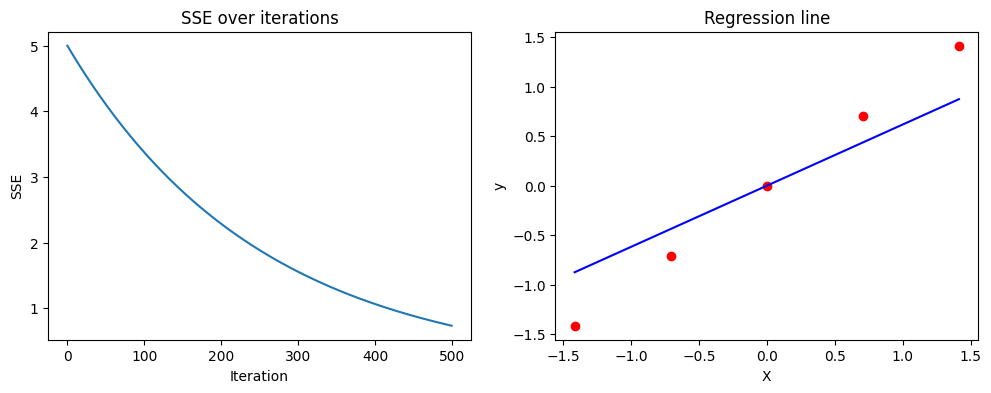

In [22]:
x_norm = normalize(x)
y_norm = normalize(y)

# Original model (no regularization)
model_raw = LinearRegressionGD(learning_rate=0.00001, n_iters=100)
model_raw.fit(x, y)

# Model with normalized input, no regularization
model_norm = LinearRegressionGD(learning_rate=0.00001, n_iters=100)
model_norm.fit(x_norm, y)

# Model with Ridge regularization (l1_ratio=0)
model_ridge = LinearRegressionGD(learning_rate=0.001, n_iters=500, alpha=0.1, l1_ratio=0.0)
model_ridge.fit(x_norm, y_norm)

# Model with Lasso regularization (l1_ratio=1)
model_lasso = LinearRegressionGD(learning_rate=0.001, n_iters=500, alpha=0.01, l1_ratio=1.0)
model_lasso.fit(x_norm, y_norm)

# Model with Elastic Net regularization (mix of L1 and L2)
model_elasticnet = LinearRegressionGD(learning_rate=0.001, n_iters=500, alpha=0.05, l1_ratio=0.5)
model_elasticnet.fit(x_norm, y_norm)

print("--- Single Feature Models ---")
print(f"Raw (no norm, no reg) - theta_1: {model_raw.theta_1:.4f}, MSE: {model_raw.mse(x, y):.4f}")
print(f"Norm (no reg) - theta_1: {model_norm.theta_1:.4f}, MSE: {model_norm.mse(x_norm, y):.4f}")
print(f"Ridge (norm) - theta_0: {model_ridge.theta_0:.4f}, theta_1: {model_ridge.theta_1:.4f}, MSE: {model_ridge.mse(x_norm, y_norm):.4f}")
print(f"Lasso (norm) - theta_0: {model_lasso.theta_0:.4f}, theta_1: {model_lasso.theta_1:.4f}, MSE: {model_lasso.mse(x_norm, y_norm):.4f}")
print(f"ElasticNet (norm) - theta_0: {model_elasticnet.theta_0:.4f}, theta_1: {model_elasticnet.theta_1:.4f}, MSE: {model_elasticnet.mse(x_norm, y_norm):.4f}")

model_ridge.plot_training(x_norm, y_norm)
model_lasso.plot_training(x_norm, y_norm)
model_elasticnet.plot_training(x_norm, y_norm)

In [23]:
print(f"MSE: {model_raw.mse(x, y):.4f}")
print(f"MSE: {model_norm.mse(x_norm, y):.4f}")

MSE: 0.0001
MSE: 45716.7649


In [24]:
class LinearRegressionGD_Multi:
    def __init__(self, learning_rate=0.01, n_iters=100, alpha=0.0, l1_ratio=0.0):
        self.lr = learning_rate
        self.n_iters = n_iters
        self.theta = None
        self.sse_history = []
        self.alpha = alpha
        self.l1_ratio = l1_ratio

    def fit(self, X, y):
        n_samples, n_features = X.shape
        X_b = np.c_[np.ones(n_samples), X]
        self.theta = np.zeros(n_features + 1)

        for _ in range(self.n_iters):
            y_pred = X_b @ self.theta

            # Unregularized gradient
            gradient = (2/n_samples) * X_b.T @ (y_pred - y)

            if self.alpha > 0:
                # L2 (Ridge) term
                gradient[1:] += self.alpha * (1 - self.l1_ratio) * 2 * self.theta[1:]
                # L1 (Lasso) term
                gradient[1:] += self.alpha * self.l1_ratio * np.sign(self.theta[1:])

            self.theta -= self.lr * gradient

            sse = np.sum((y - y_pred) ** 2)
            self.sse_history.append(sse)

    def predict(self, X):
        X_b = np.c_[np.ones(X.shape[0]), X]
        return X_b @ self.theta

    def mse(self, X, y):
        return np.mean((y - self.predict(X)) ** 2)

    def plot_training(self):
        plt.plot(self.sse_history)
        plt.title('SSE over iterations')
        plt.xlabel('Iteration')
        plt.ylabel('SSE')
        plt.show()

--- Multi-Feature Models ---
No Regularization:
  Theta: [-0.33428135  1.3626902   0.98888442]
  MSE: 0.00845196891595103
Ridge Regularization:
  Theta: [-0.39560187  1.11458715  0.66882862]
  MSE: 0.05570828717948961
Lasso Regularization:
  Theta: [-0.35118879  1.35458073  0.96098378]
  MSE: 0.008373751947539953
Elastic Net Regularization:
  Theta: [-0.39957105  1.27221241  0.82162775]
  MSE: 0.01641488861719067


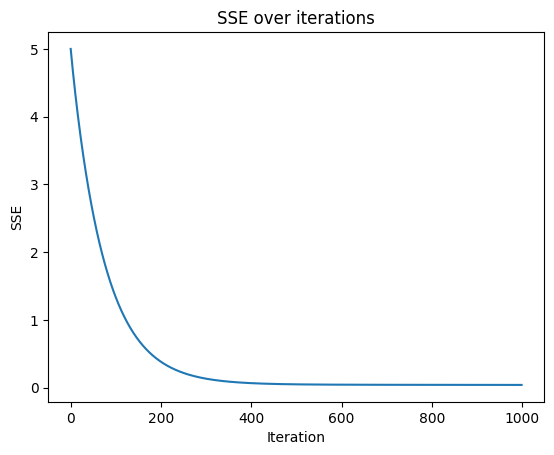

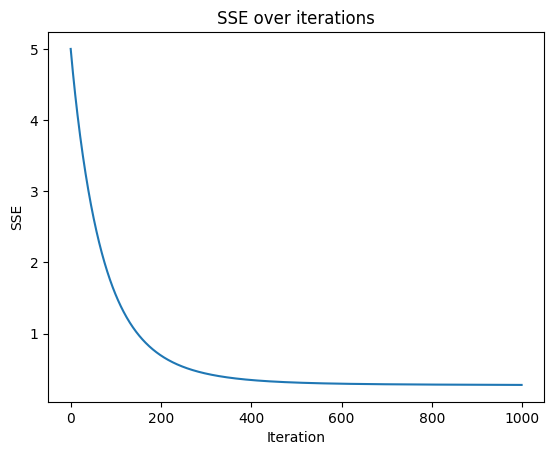

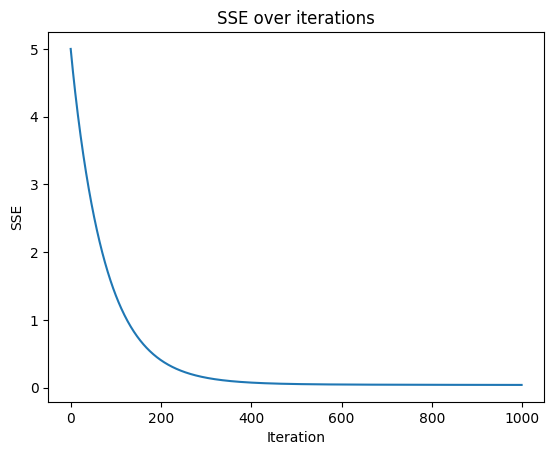

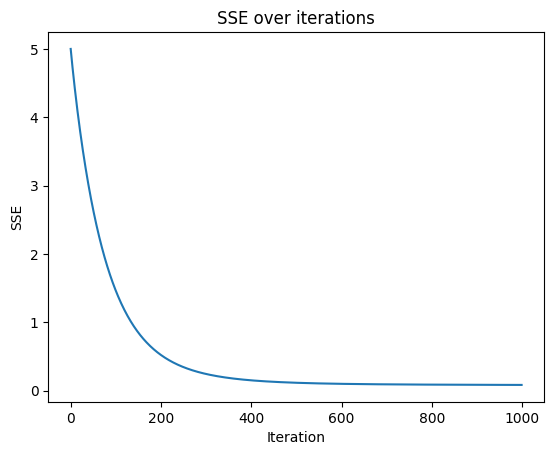

In [25]:
X_multi = np.array([
    [50, 10],
    [60, 20],
    [70, 20],
    [80, 30],
    [90, 30]
])
y = np.array([150, 180, 210, 240, 270])

X_multi_norm = normalize(X_multi)
y_norm = normalize(y)

# Original multi-feature model (no regularization)
model_multi = LinearRegressionGD_Multi(learning_rate=0.01, n_iters=1000)
model_multi.fit(X_multi_norm, y_norm)

# Multi-feature model with Ridge regularization
model_multi_ridge = LinearRegressionGD_Multi(learning_rate=0.01, n_iters=1000, alpha=0.1, l1_ratio=0.0)
model_multi_ridge.fit(X_multi_norm, y_norm)

# Multi-feature model with Lasso regularization
model_multi_lasso = LinearRegressionGD_Multi(learning_rate=0.01, n_iters=1000, alpha=0.01, l1_ratio=1.0)
model_multi_lasso.fit(X_multi_norm, y_norm)

# Multi-feature model with Elastic Net regularization
model_multi_elasticnet = LinearRegressionGD_Multi(learning_rate=0.01, n_iters=1000, alpha=0.05, l1_ratio=0.5)
model_multi_elasticnet.fit(X_multi_norm, y_norm)

print("--- Multi-Feature Models ---")
print("No Regularization:")
print("  Theta:", model_multi.theta)
print("  MSE:", model_multi.mse(X_multi_norm, y_norm))

print("Ridge Regularization:")
print("  Theta:", model_multi_ridge.theta)
print("  MSE:", model_multi_ridge.mse(X_multi_norm, y_norm))

print("Lasso Regularization:")
print("  Theta:", model_multi_lasso.theta)
print("  MSE:", model_multi_lasso.mse(X_multi_norm, y_norm))

print("Elastic Net Regularization:")
print("  Theta:", model_multi_elasticnet.theta)
print("  MSE:", model_multi_elasticnet.mse(X_multi_norm, y_norm))

model_multi.plot_training()
model_multi_ridge.plot_training()
model_multi_lasso.plot_training()
model_multi_elasticnet.plot_training()

### Polynomial Regression

In [26]:
class PolynomialRegressionGD:
    """
    Polynomial Regression using Gradient Descent
    Wraps LinearRegressionGD_Multi to add polynomial features.
    """
    def __init__(self, degree=2, learning_rate=0.01, n_iters=100, alpha=0.0, l1_ratio=0.0):
        if degree < 1:
            raise ValueError("Degree must be at least 1 for polynomial features.")
        self.degree = degree
        # Initialize an instance of LinearRegressionGD_Multi
        self.linear_model = LinearRegressionGD_Multi(learning_rate=learning_rate,
                                                    n_iters=n_iters,
                                                    alpha=alpha,
                                                    l1_ratio=l1_ratio)
        self.theta = None

    def _polynomial_features(self, X):
        """
        Transforms input features X into polynomial features of specified degree.
        If X is 1D, it becomes a 2D array before transformation.
        The intercept term (X^0) is handled by LinearRegressionGD_Multi's X_b, so we start from X^1.
        """
        if X.ndim == 1:
            X = X.reshape(-1, 1)

        # Start with the original features (X^1)
        X_poly = X
        # Add higher-order polynomial terms
        for d in range(2, self.degree + 1):
            X_poly = np.hstack((X_poly, X**d))
        return X_poly

    def fit(self, X, y):
        # Transform X to polynomial features
        X_poly = self._polynomial_features(X)
        self.linear_model.fit(X_poly, y)
        self.sse_history = self.linear_model.sse_history
        self.theta = self.linear_model.theta # Store the theta from the underlying linear model

    def predict(self, X):
        X_poly = self._polynomial_features(X)
        return self.linear_model.predict(X_poly)

    def mse(self, X, y):
        return self.linear_model.mse(self._polynomial_features(X), y)

    def plot_training(self):
        self.linear_model.plot_training()

    def plot_regression(self, X, y):
        if X.ndim > 1 and X.shape[1] > 1:
            print("Cannot plot 2D regression surface directly for multiple original features.")
            return

        plt.figure(figsize=(8, 6))
        plt.scatter(X, y, color='red', label='Actual data')

        # Generate points for the regression line
        x_min, x_max = np.min(X), np.max(X)
        x_line = np.linspace(x_min, x_max, 100).reshape(-1, 1)
        y_line = self.predict(x_line)

        plt.plot(x_line, y_line, color='blue', label=f'Polynomial Regression (Degree {self.degree})')
        plt.title(f'Polynomial Regression (Degree {self.degree})')
        plt.xlabel('X')
        plt.ylabel('y')
        plt.legend()
        plt.show()

Let's generate some synthetic non-linear data to demonstrate polynomial regression.

--- Polynomial Regression Model (Degree 3) ---
Theta: [ 0.71506876  0.180815   -0.71506939  0.28500454]
MSE: 0.05929298870226841


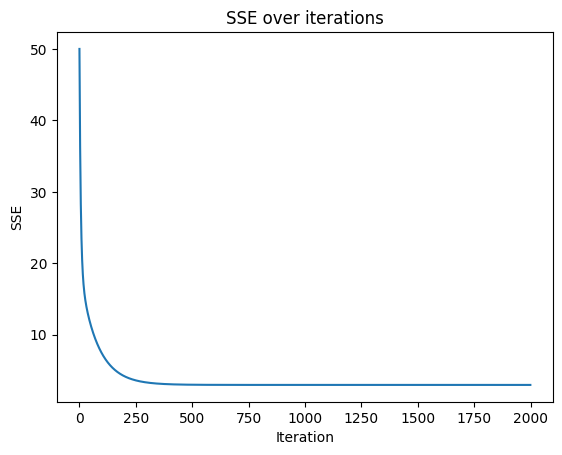

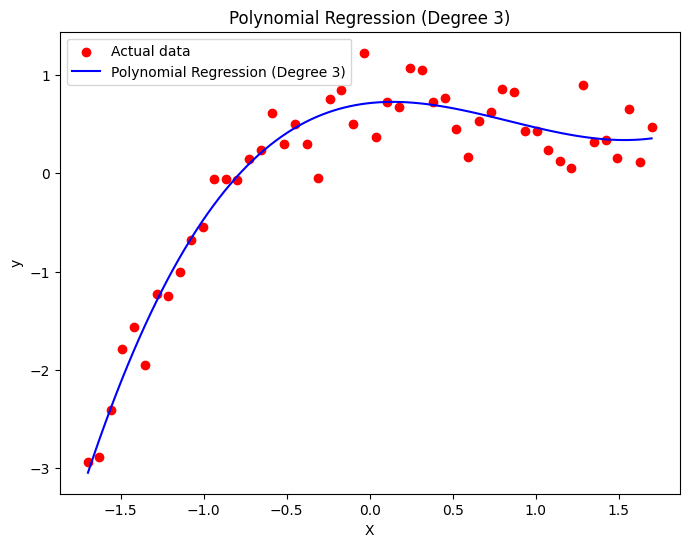


--- Polynomial Regression Model (Degree 1 - Underfit) ---
Theta: [1.67360158e-16 6.93317637e-01]
MSE: 0.5184833057117632


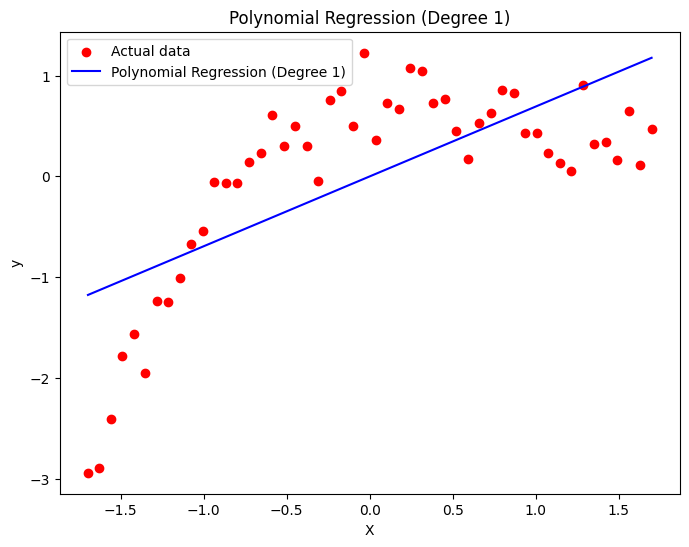


--- Polynomial Regression Model (Degree 5) ---
Theta: [ 0.69104197  0.22546229 -0.6634885   0.2191804  -0.01646138  0.01925047]
MSE: 0.059839007541084566


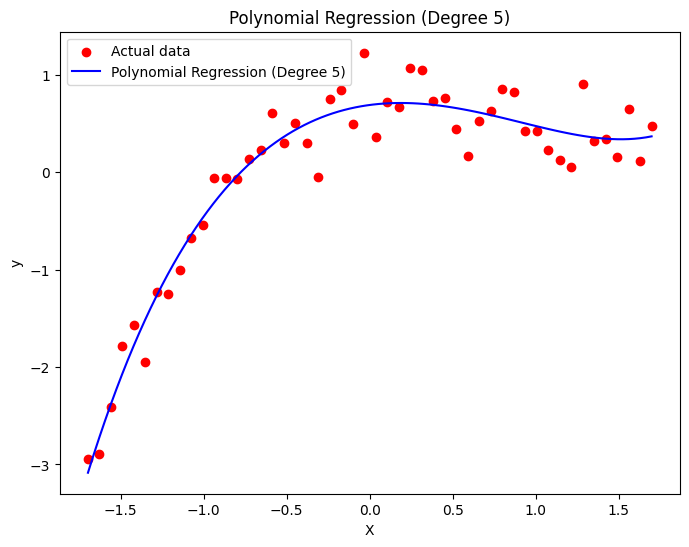

In [27]:
# Generate synthetic data for polynomial regression
np.random.seed(0)
X_poly_data = np.linspace(-3, 3, 50).reshape(-1, 1)
y_poly_data = 0.5 * X_poly_data**3 - 2 * X_poly_data**2 + X_poly_data + np.random.randn(50, 1) * 2

# Normalize the data for better performance with GD and regularization
X_poly_data_norm = normalize(X_poly_data)
y_poly_data_norm = normalize(y_poly_data.flatten()) # Flatten y to 1D array as expected by normalize

# Train a Polynomial Regression model (degree 3)
print("--- Polynomial Regression Model (Degree 3) ---")
poly_model_deg3 = PolynomialRegressionGD(degree=3, learning_rate=0.01, n_iters=2000, alpha=0.001, l1_ratio=0.5)
poly_model_deg3.fit(X_poly_data_norm, y_poly_data_norm)

print("Theta:", poly_model_deg3.theta)
print("MSE:", poly_model_deg3.mse(X_poly_data_norm, y_poly_data_norm))

poly_model_deg3.plot_training()
poly_model_deg3.plot_regression(X_poly_data_norm, y_poly_data_norm)

# Demonstrate with a lower degree (underfitting)
print("\n--- Polynomial Regression Model (Degree 1 - Underfit) ---")
poly_model_underfit = PolynomialRegressionGD(degree=1, learning_rate=0.01, n_iters=2000, alpha=0.001, l1_ratio=0.5)
poly_model_underfit.fit(X_poly_data_norm, y_poly_data_norm)
print("Theta:", poly_model_underfit.theta)
print("MSE:", poly_model_underfit.mse(X_poly_data_norm, y_poly_data_norm))
poly_model_underfit.plot_regression(X_poly_data_norm, y_poly_data_norm)

# Demonstrate with a higher degree (potential overfitting or better fit)
print("\n--- Polynomial Regression Model (Degree 5) ---")
poly_model_overfit = PolynomialRegressionGD(degree=5, learning_rate=0.01, n_iters=2000, alpha=0.001, l1_ratio=0.5)
poly_model_overfit.fit(X_poly_data_norm, y_poly_data_norm)
print("Theta:", poly_model_overfit.theta)
print("MSE:", poly_model_overfit.mse(X_poly_data_norm, y_poly_data_norm))
poly_model_overfit.plot_regression(X_poly_data_norm, y_poly_data_norm)

In [28]:
#finish